In [1]:
import ollama
import json
import lancedb
from lancedb.rerankers import ColbertReranker
from tqdm.notebook import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from devtools import debug
import instructor

METRICS_FIGURE_NAME = "Contextual retrieval performance metrics (document slice only)"

# QNA_FILE_PATH = "q_and_a/Gemini/scientific_multi_chunk_control.json"
QNA_FILE_PATH = "q_and_a/Gemini/scientific_multi_chunk_control.json"

MODEL_TAG = "qwen3-vl:8b-instruct-q4_K_M"
# hybrid_table has all the data as anthropic_control_table, except it doesn't use the context for anything, and embeddings are generated from the original text.
TABLE_NAMES = ["hybrid_retrieval"] + [f"ablation_doc_slice_radius_{i}" for i in range(0,5)] + ["anthropic_control_table"]
TABLE_NAMES

/home/martin/projects/TDK/Document_Slice_Contextual_Retrieval/.venv/lib/python3.13/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in ColPaliEmbeddings has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/martin/projects/TDK/Document_Slice_Contextual_Retrieval/.venv/lib/python3.13/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in SigLipEmbeddings has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


['hybrid_retrieval',
 'ablation_doc_slice_radius_0',
 'ablation_doc_slice_radius_1',
 'ablation_doc_slice_radius_2',
 'ablation_doc_slice_radius_3',
 'ablation_doc_slice_radius_4',
 'anthropic_control_table']

In [2]:
db = lancedb.connect("./db")
tables = {table_name: db.open_table(table_name) for table_name in TABLE_NAMES}


reranker = ColbertReranker()

with open(QNA_FILE_PATH, "r") as f:
	qna = json.load(f)

Loading ColBERTRanker model colbert-ir/colbertv2.0 (this message can be suppressed by setting verbose=0)
No device set
Using device cuda
No dtype set
Using dtype torch.float32
Loading model colbert-ir/colbertv2.0, this might take a while...
Linear Dim set to: 128 for downcasting


In [3]:
qna[0]['question']

'How did the distinct components of the Gander project inform the structure of the derived conceptual framework for open science in software engineering?'

In [4]:
import numpy as np

own_metrics_per_question = []
baseline_metrics_per_question = []

own_avg_recall_at_n = {}
own_mrr_at_n = {}
own_mar_at_n = {}

recall_diffs_at_n = {5: [], 10: [], 15: [], 20: []}

for question in tqdm(qna, desc="Processing questions..."):
	question_prompt = question["question"]
	supporting_chunk_ids = set(question["supporting_chunks"])

	own_metrics = {i: {name: {} for name in TABLE_NAMES} for i in range(5, 21, 5)}

	for name, table in tables.items():
     
		own_df = table.search(question_prompt, query_type="hybrid", vector_column_name="vector", fts_columns="text") \
				.rerank(reranker=reranker) \
				.limit(20) \
				.to_pandas()
   
		for i in range(5,21,5):
			own_df_cutoff = own_df.head(i)

			own_retreived_chunk_ids = own_df_cutoff['id'].tolist()
			own_recall_at_i = sum([1 if id in supporting_chunk_ids else 0 for id in own_retreived_chunk_ids]) / len(supporting_chunk_ids)

			own_metrics[i][name] = {'recall': 0.0, 'reciprocal_rank': np.nan}
			own_metrics[i][name]['recall'] = own_recall_at_i

			first_relevant_found = False
			relevant_chunk_ranks = []
			for rank, chunk in enumerate(own_retreived_chunk_ids):
				if chunk in supporting_chunk_ids:
					if not first_relevant_found:
						own_metrics[i][name]['reciprocal_rank'] = 1.0 / (rank + 1)
						first_relevant_found = True
					relevant_chunk_ranks.append(rank + 1)
			
			own_metrics[i][name]['average_rank'] = sum(relevant_chunk_ranks) / len(relevant_chunk_ranks) if len(relevant_chunk_ranks) > 0 else np.nan

	own_metrics_per_question.append(own_metrics)
own_metrics_per_question[0]

Processing questions...:   0%|          | 0/250 [00:00<?, ?it/s]

<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>


{5: {'hybrid_retrieval': {'recall': 0.6666666666666666,
   'reciprocal_rank': 1.0,
   'average_rank': 2.5},
  'ablation_doc_slice_radius_0': {'recall': 0.6666666666666666,
   'reciprocal_rank': 1.0,
   'average_rank': 2.0},
  'ablation_doc_slice_radius_1': {'recall': 0.6666666666666666,
   'reciprocal_rank': 0.5,
   'average_rank': 2.5},
  'ablation_doc_slice_radius_2': {'recall': 0.6666666666666666,
   'reciprocal_rank': 0.5,
   'average_rank': 2.5},
  'ablation_doc_slice_radius_3': {'recall': 0.6666666666666666,
   'reciprocal_rank': 0.3333333333333333,
   'average_rank': 4.0},
  'ablation_doc_slice_radius_4': {'recall': 0.6666666666666666,
   'reciprocal_rank': 0.5,
   'average_rank': 2.5},
  'anthropic_control_table': {'recall': 0.6666666666666666,
   'reciprocal_rank': 1.0,
   'average_rank': 2.0}},
 10: {'hybrid_retrieval': {'recall': 1.0,
   'reciprocal_rank': 1.0,
   'average_rank': 4.333333333333333},
  'ablation_doc_slice_radius_0': {'recall': 1.0,
   'reciprocal_rank': 1.0,


In [5]:
with open("ablation_results_2.json", "w", encoding="utf-8") as f:
    json.dump(own_metrics_per_question, f, ensure_ascii=False, indent=2)


In [6]:
own_avg_recall_at_n = {i:{name: None for name in TABLE_NAMES} for i in range(5, 21, 5)}
own_mrr_at_n = {i:{name: None for name in TABLE_NAMES} for i in range(5, 21, 5)}
own_mar_at_n = {i:{name: None for name in TABLE_NAMES} for i in range(5, 21, 5)}

In [7]:
import numpy as np

for name in TABLE_NAMES:
	for i in range(5,21,5):
		own_avg_recall_at_n[i][name] = np.average([metrics[i][name]['recall'] for metrics in own_metrics_per_question])
		
		own_mrr_at_n[i][name] = np.nanmean([metrics[i][name]['reciprocal_rank'] for metrics in own_metrics_per_question])
		
		own_mar_at_n[i][name] = np.nanmean([metrics[i][name]['average_rank'] for metrics in own_metrics_per_question])

		print("-"*50)
		print(f"METRICS AT N={i:<2} | {name}")
		print("-"*50)
		print(f"RECALL          | {round(own_avg_recall_at_n[i][name],5):<11}")
		print(f"MRR             | {round(own_mrr_at_n[i][name],5):<11}")
		print(f"MAR             | {round(own_mar_at_n[i][name],5):<11}\n\n")



--------------------------------------------------
METRICS AT N=5  | hybrid_retrieval
--------------------------------------------------
RECALL          | 0.71733    
MRR             | 0.82302    
MAR             | 2.12518    


--------------------------------------------------
METRICS AT N=10 | hybrid_retrieval
--------------------------------------------------
RECALL          | 0.847      
MRR             | 0.78924    
MAR             | 2.94067    


--------------------------------------------------
METRICS AT N=15 | hybrid_retrieval
--------------------------------------------------
RECALL          | 0.918      
MRR             | 0.77484    
MAR             | 3.71841    


--------------------------------------------------
METRICS AT N=20 | hybrid_retrieval
--------------------------------------------------
RECALL          | 0.93933    
MRR             | 0.77484    
MAR             | 4.03629    


--------------------------------------------------
METRICS AT N=5  | ablation_doc_sl

In [10]:
import matplotlib.pyplot as plt
from pydantic import BaseModel, ValidationError, Field, model_validator 
from typing import List, Self
import math


class BarChartData(BaseModel):
    """
    Schema for validating bar chart data.
    Ensures data consistency before visualization.
    """
    labels: List[str] = Field(..., description="Names of the bars")
    values: List[float] = Field(..., description="Numerical values for the bars")
    title: str = Field(..., description="Title of the chart")
    x_label: str = Field(..., description="Label for the x-axis")
    y_label: str = Field(..., description="Label for the y-axis")

    @model_validator(mode="after")
    def check_length_match(self) -> Self:
        if len(self.labels) != len(self.values):
            raise ValidationError(f"There is different number of labels and values!\n{self.labels=}\n{self.values=}")
        return self
    

def create_annotated_bar_chart(data: BarChartData, output_file: str = 'annotated_bar_chart.png'):
    """
    Generates a bar chart with explicit value annotations above each bar.
    """
    # Create the figure and axis explicitly for better control
    fig, ax = plt.subplots()
    ax.tick_params(axis='x', rotation=30)
    
    cmap = plt.get_cmap('magma')
    norm_y = (data.values - np.min(data.values)) / (np.max(data.values) - np.min(data.values))
    colors = [cmap(val) for val in norm_y]
    
    # Capture the container of bars to access their properties later
    bars = ax.bar(data.labels, data.values, color=colors)
    
    ax.bar_label(bars, padding=3)

    ax.set_xlabel(data.x_label)
    ax.set_ylabel(data.y_label)
    ax.set_title(data.title)
    
    # Dynamic Y-Axis Adjustment
    # Crucial: Increase the y-axis limit by 10% to prevent the text from being cut off at the top
    ax.set_ylim(0, max(data.values) * 1.1)
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Always close the plot to free memory in batch processing
    
def create_multi_bar_chart(data_list: List[BarChartData], output_file: str = 'multi_plot.png'):
    """
    Generates a figure containing subplots for each BarChartData instance.
    Dynamically calculates grid dimensions.
    """
    n = len(data_list)
    if n == 0:
        raise ValueError("Input list is empty.")

    # 1. Calculate Grid Dimensions
    # We aim for a roughly square grid, prioritizing width (max 3 columns)
    cols = min(n, 2)
    rows = math.ceil(n / cols)
    
    # Calculate figure size: 6 inches per col, 5 inches per row
    figsize = (6 * cols, 5 * rows)

    # 2. Create Subplots
    # squeeze=False ensures axes is always a 2D array, simplifying indexing
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    
    # Flatten axes array for easy 1D iteration
    axes_flat = axes.flatten()

    # 3. Plotting Loop
    for i, data in enumerate(data_list):
        ax = axes_flat[i]
        
        # Original Plotting Logic applied to specific axis
        bars = ax.bar(data.labels, data.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        
        # Native matplotlib annotation (requires matplotlib >= 3.4.0)
        ax.bar_label(bars, padding=3, fmt='%.5f')

        ax.set_xlabel('Categories')
        ax.set_ylabel('Values')
        ax.set_title(data.title)
        
        # Dynamic Y-Axis Adjustment for headroom
        if data.values:
            ax.set_ylim(0, max(data.values) * 1.15)

    # 4. Cleanup Unused Axes
    # If we have a 2x2 grid (4 slots) but only 3 data items, turn off the 4th slot
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    # Adjust layout to prevent overlapping titles/labels
    plt.tight_layout()
    
    plt.savefig(output_file, dpi=300)
    plt.close()


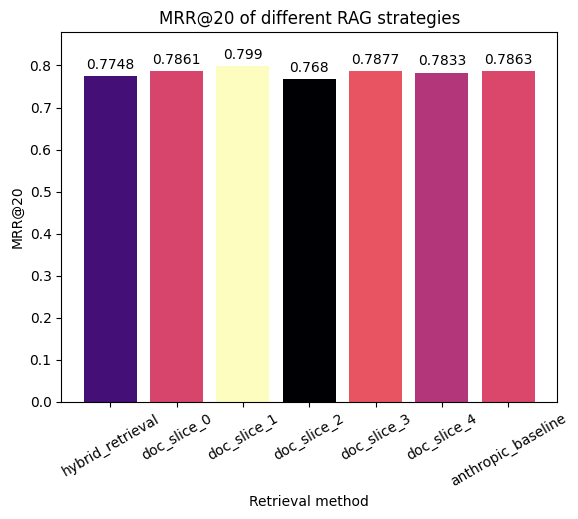

In [14]:
labels = ["hybrid_retrieval"] + [f"doc_slice_{i}" for i in range(0,5)] + ["anthropic_baseline"]
ablation_recall = BarChartData(labels=labels, values=[round(own_mrr_at_n[20][name],4) for name in TABLE_NAMES], title="MRR@20 of different RAG strategies", x_label="Retrieval method", y_label="MRR@20")

# create_annotated_bar_chart(data=emission_data, output_file="benchmarking_results/preprocessing/emissions.png")
create_annotated_bar_chart(data=ablation_recall, output_file="benchmarking_results/doc_slice_ablation/mrr_20_v2.png")
# create_multi_bar_chart([emission_data, energy_data], 'benchmarking_results/preprocessing/eco_friendliness.png')

In [15]:
own_avg_recall_at_n[5]

{'hybrid_retrieval': 0.7173333333333333,
 'ablation_doc_slice_radius_0': 0.757,
 'ablation_doc_slice_radius_1': 0.7563333333333333,
 'ablation_doc_slice_radius_2': 0.7453333333333333,
 'ablation_doc_slice_radius_3': 0.741,
 'ablation_doc_slice_radius_4': 0.7333333333333333,
 'anthropic_control_table': 0.7373333333333333}

In [11]:
ht = tables["hybrid_retrieval"].search().where("id = '9508e04dcdac204129b03bc4f75f8abb35639ef51102d568119f6f033c400631'").to_pandas().text
ht.get(0)

"Christoph Schweimer ͷ , Bernhard C. Geiger ͷ * , Meizhu Wang ͷ , Sergiy Gogolenko \u0378 , Imran Mahmood \u0379 , Alireza Jahani \u0379 , Diana Suleimenova \u0379 * & Derek Groen \u0379, ͅ\nAutomated construction of location graphs is instrumental but challenging, particularly in logistics optimisation problems and agent-based movement simulations. Hence, we propose an algorithm for automated construction of location graphs, in which vertices correspond to geographic locations of interest and edges to direct travelling routes between them. Our approach involves two steps. In the first step, we use a routing service to compute distances between all pairs of L locations, resulting in a complete graph. In the second step, we prune this graph by removing edges corresponding to indirect routes, identified using the triangle inequality. The computational complexity of this second step is O ( L 3 ) , which enables the computation of location graphs for all towns and cities on the road networ

In [12]:
at = tables["anthropic_control_table"].search().where("id = '9508e04dcdac204129b03bc4f75f8abb35639ef51102d568119f6f033c400631'").to_pandas().text
at.get(0)

"Proposes an algorithm for automated location graph construction, utilizing a two-step process: computing pairwise distances and pruning indirect routes based on the triangle inequality. This approach achieves high precision and recall values, enabling the creation of large location graphs for which manual creation is infeasible.\n\nChristoph Schweimer ͷ , Bernhard C. Geiger ͷ * , Meizhu Wang ͷ , Sergiy Gogolenko \u0378 , Imran Mahmood \u0379 , Alireza Jahani \u0379 , Diana Suleimenova \u0379 * & Derek Groen \u0379, ͅ\nAutomated construction of location graphs is instrumental but challenging, particularly in logistics optimisation problems and agent-based movement simulations. Hence, we propose an algorithm for automated construction of location graphs, in which vertices correspond to geographic locations of interest and edges to direct travelling routes between them. Our approach involves two steps. In the first step, we use a routing service to compute distances between all pairs of 